# 📊 UK Wind Power Forecast Error Analysis

This notebook analyses the error characteristics of the WINDFOR (wind power forecast) dataset from Elexon BMRS.

**Dataset**: January 2024 · UK National Wind Generation

**Goals**:
- Understand the distribution of forecast errors (MAE, RMSE, MBE, P99)
- Examine how error varies with forecast horizon
- Examine how error varies by time-of-day and day-of-week

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from datetime import datetime, timedelta, timezone

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1a0f',
    'axes.facecolor': '#111a11',
    'axes.edgecolor': '#2a3a2a',
    'axes.labelcolor': '#8dab82',
    'xtick.color': '#4d6647',
    'ytick.color': '#4d6647',
    'grid.color': '#1e2e1e',
    'grid.linestyle': '--',
    'text.color': '#e8f5e2',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titlecolor': '#e8f5e2',
    'legend.facecolor': '#111a11',
    'legend.edgecolor': '#2a3a2a',
})

ACTUAL_COLOR = '#60a5fa'
FORECAST_COLOR = '#4ade80'
ERROR_COLOR = '#fbbf24'
NEG_ERROR_COLOR = '#f87171'

print('Libraries loaded.')

Libraries loaded.


## 1. Fetch Data from Elexon BMRS API

In [2]:
BASE_URL = 'https://data.elexon.co.uk/bmrs/api/v1'

def fetch_stream(endpoint: str, params: dict, max_retries: int = 3) -> list:
    """Fetch data from an Elexon BMRS stream endpoint."""
    url = f'{BASE_URL}/{endpoint}'
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, params=params, timeout=60)
            resp.raise_for_status()
            data = resp.json()
            if isinstance(data, list):
                return data
            return data.get('data', data.get('items', []))
        except Exception as e:
            print(f'  Attempt {attempt+1} failed: {e}')
            if attempt == max_retries - 1:
                raise
    return []

# Fetch actual wind generation for Jan 2024
print('Fetching actual generation (FUELHH)...')
actual_raw = fetch_stream('datasets/FUELHH/stream', {
    'publishDateTimeFrom': '2024-01-01T00:00Z',
    'publishDateTimeTo': '2024-01-31T23:59Z',
})

print(f'  Raw records: {len(actual_raw)}')
df_actual_raw = pd.DataFrame(actual_raw)
print(f'  Columns: {df_actual_raw.columns.tolist()}')

Fetching actual generation (FUELHH)...
  Raw records: 28272
  Columns: ['dataset', 'publishTime', 'startTime', 'settlementDate', 'settlementPeriod', 'fuelType', 'generation']


In [3]:
# Filter for WIND fuel type
df_actual = df_actual_raw[df_actual_raw['fuelType'].str.upper() == 'WIND'].copy()
df_actual['startTime'] = pd.to_datetime(df_actual['startTime'], utc=True)
df_actual['generation'] = pd.to_numeric(df_actual['generation'], errors='coerce')
df_actual = df_actual[['startTime', 'generation']].drop_duplicates('startTime').sort_values('startTime')
df_actual.set_index('startTime', inplace=True)

print(f'Actual wind records: {len(df_actual)}')
print(f'Date range: {df_actual.index.min()} → {df_actual.index.max()}')
print(f'Generation range: {df_actual["generation"].min():.0f} – {df_actual["generation"].max():.0f} MW')
df_actual.head()

Actual wind records: 1488
Date range: 2023-12-31 23:30:00+00:00 → 2024-01-31 23:00:00+00:00
Generation range: 0 – 16662 MW


,generation
startTime,
2023-12-31 23:30:00+00:00,9980
2024-01-01 00:00:00+00:00,10402
2024-01-01 00:30:00+00:00,10845
2024-01-01 01:00:00+00:00,11218
2024-01-01 01:30:00+00:00,11223


In [4]:
# Fetch forecast data for Jan 2024 (extended back 48h for horizon coverage)
print('Fetching forecast data (WINDFOR)...')
forecast_raw = fetch_stream('datasets/WINDFOR/stream', {
    'publishDateTimeFrom': '2023-12-30T00:00Z',  # 48h before Jan 1 to capture all forecasts
    'publishDateTimeTo': '2024-01-31T23:59Z',
})

print(f'  Raw forecast records: {len(forecast_raw)}')
df_fc_raw = pd.DataFrame(forecast_raw)
print(f'  Columns: {df_fc_raw.columns.tolist()}')

Fetching forecast data (WINDFOR)...
  Raw forecast records: 12936
  Columns: ['dataset', 'publishTime', 'startTime', 'generation']


In [5]:
# Parse forecast dataframe
df_fc = df_fc_raw.copy()

# Detect column names (Elexon may vary)
pub_col = next((c for c in df_fc.columns if 'publish' in c.lower()), 'publishTime')
start_col = next((c for c in df_fc.columns if 'starttime' in c.lower() or 'start_time' in c.lower()), 'startTime')
gen_col = next((c for c in df_fc.columns if 'generation' in c.lower() or 'quantity' in c.lower()), 'generation')

df_fc['startTime'] = pd.to_datetime(df_fc[start_col], utc=True)
df_fc['publishTime'] = pd.to_datetime(df_fc[pub_col], utc=True)
df_fc['generation'] = pd.to_numeric(df_fc[gen_col], errors='coerce')

# Filter: startTime within Jan 2024
df_fc = df_fc[
    (df_fc['startTime'] >= '2024-01-01') &
    (df_fc['startTime'] <= '2024-01-31T23:59Z')
]

# Compute horizon (hours between publishTime and startTime)
df_fc['horizon_h'] = (df_fc['startTime'] - df_fc['publishTime']).dt.total_seconds() / 3600

# Filter: horizon between 0 and 48h
df_fc = df_fc[(df_fc['horizon_h'] >= 0) & (df_fc['horizon_h'] <= 48)]
df_fc = df_fc[['startTime', 'publishTime', 'generation', 'horizon_h']].dropna()

print(f'Forecast records (Jan 2024, 0–48h horizon): {len(df_fc)}')
print(f'Horizon range: {df_fc["horizon_h"].min():.1f} – {df_fc["horizon_h"].max():.1f} h')
df_fc.head()

Forecast records (Jan 2024, 0–48h horizon): 9582
Horizon range: 0.5 – 48.0 h


,startTime,publishTime,generation,horizon_h
2,2024-01-31 23:00:00+00:00,2024-01-31 22:30:00+00:00,16909,0.5
49,2024-01-31 21:00:00+00:00,2024-01-31 18:30:00+00:00,17912,2.5
50,2024-01-31 22:00:00+00:00,2024-01-31 18:30:00+00:00,17670,3.5
51,2024-01-31 23:00:00+00:00,2024-01-31 18:30:00+00:00,17275,4.5
98,2024-01-31 21:00:00+00:00,2024-01-31 15:30:00+00:00,17887,5.5


## 2. Construct Paired Dataset

For each actual data point at time T, find the latest forecast published at or before T − horizon_h, for each discrete horizon.

In [6]:
def get_best_forecast_for_horizon(df_actuals: pd.DataFrame, df_forecasts: pd.DataFrame, horizon_h: float) -> pd.DataFrame:
    """
    For each actual point (target time T, actual generation A):
      - Find all forecasts with startTime == T and publishTime <= T - horizon_h
      - Pick the one with the latest publishTime (most recent eligible forecast)
    """
    results = []
    horizon_delta = pd.Timedelta(hours=horizon_h)
    
    for target_time, row in df_actuals.iterrows():
        cutoff = target_time - horizon_delta
        # Match forecasts to this target time (within ±15 min to handle rounding)
        candidates = df_forecasts[
            (df_forecasts['startTime'] >= target_time - pd.Timedelta(minutes=15)) &
            (df_forecasts['startTime'] <= target_time + pd.Timedelta(minutes=15)) &
            (df_forecasts['publishTime'] <= cutoff)
        ]
        
        if len(candidates) == 0:
            continue
        
        best = candidates.loc[candidates['publishTime'].idxmax()]
        results.append({
            'targetTime': target_time,
            'actual': row['generation'],
            'forecast': best['generation'],
            'publishTime': best['publishTime'],
            'horizon_h': horizon_h,
        })
    
    return pd.DataFrame(results)

# Build paired dataset at 4h horizon (default)
print('Pairing actuals with forecasts at 4h horizon...')
df_paired = get_best_forecast_for_horizon(df_actual, df_fc, horizon_h=4.0)
df_paired['error'] = df_paired['forecast'] - df_paired['actual']
df_paired['abs_error'] = df_paired['error'].abs()

print(f'Paired records: {len(df_paired)}')
df_paired.head()

Pairing actuals with forecasts at 4h horizon...
Paired records: 744


,targetTime,actual,forecast,publishTime,horizon_h,error,abs_error
0,2024-01-01 00:00:00+00:00,10402,11453,2023-12-31 18:30:00+00:00,4.0,1051,1051
1,2024-01-01 01:00:00+00:00,11218,11841,2023-12-31 18:30:00+00:00,4.0,623,623
2,2024-01-01 02:00:00+00:00,11234,12092,2023-12-31 18:30:00+00:00,4.0,858,858
3,2024-01-01 03:00:00+00:00,11434,12428,2023-12-31 22:30:00+00:00,4.0,994,994
4,2024-01-01 04:00:00+00:00,11828,12775,2023-12-31 22:30:00+00:00,4.0,947,947


## 3. Overall Error Statistics

In [7]:
def compute_error_stats(df: pd.DataFrame, label: str = '') -> dict:
    errors = df['error']
    abs_errors = df['abs_error']
    avg_actual = df['actual'].mean()
    
    stats = {
        'n': len(df),
        'MAE': abs_errors.mean(),
        'MBE': errors.mean(),
        'RMSE': np.sqrt((errors**2).mean()),
        'P50 AbsError': abs_errors.quantile(0.50),
        'P90 AbsError': abs_errors.quantile(0.90),
        'P99 AbsError': abs_errors.quantile(0.99),
        'NMAE (%)': abs_errors.mean() / avg_actual * 100,
        'Avg Actual (MW)': avg_actual,
    }
    
    print(f'--- Error Statistics {label} ---')
    for k, v in stats.items():
        if k == 'n':
            print(f'  {k}: {v}')
        else:
            print(f'  {k}: {v:.1f}{" MW" if "MW" in k else " %" if "%" in k else " MW" if k != "n" else ""}')
    return stats

stats_4h = compute_error_stats(df_paired, label='(4h horizon)')

--- Error Statistics (4h horizon) ---
  n: 744
  MAE: 1827.7 MW
  MBE: 1181.0 MW
  RMSE: 2434.5 MW
  P50 AbsError: 1453.5 MW
  P90 AbsError: 3956.4 MW
  P99 AbsError: 6072.9 MW
  NMAE (%): 18.6 %
  Avg Actual (MW): 9849.4 MW


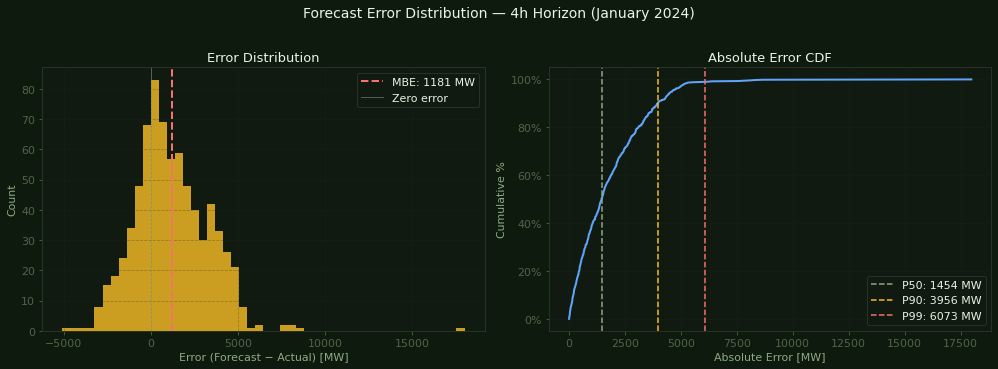

Saved: error_distribution.png


In [8]:
# Plot error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Forecast Error Distribution — 4h Horizon (January 2024)', fontsize=14, y=1.02)

# Error histogram
ax1 = axes[0]
ax1.hist(df_paired['error'], bins=50, color=ERROR_COLOR, alpha=0.8, edgecolor='none')
ax1.axvline(df_paired['error'].mean(), color='#f87171', linewidth=2, linestyle='--', label=f"MBE: {df_paired['error'].mean():.0f} MW")
ax1.axvline(0, color='#8dab82', linewidth=1, linestyle='-', alpha=0.5, label='Zero error')
ax1.set_xlabel('Error (Forecast − Actual) [MW]')
ax1.set_ylabel('Count')
ax1.set_title('Error Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Absolute error CDF
ax2 = axes[1]
sorted_abs = np.sort(df_paired['abs_error'])
cdf = np.arange(1, len(sorted_abs) + 1) / len(sorted_abs)
ax2.plot(sorted_abs, cdf * 100, color=ACTUAL_COLOR, linewidth=2)
for p, c in [(50, '#8dab82'), (90, ERROR_COLOR), (99, '#f87171')]:
    val = df_paired['abs_error'].quantile(p / 100)
    ax2.axvline(val, color=c, linestyle='--', linewidth=1.5, label=f'P{p}: {val:.0f} MW')
ax2.set_xlabel('Absolute Error [MW]')
ax2.set_ylabel('Cumulative %')
ax2.set_title('Absolute Error CDF')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: error_distribution.png')

## 4. Error vs Forecast Horizon

In [9]:
# Build paired dataset for multiple horizons
HORIZONS = [1, 2, 4, 6, 12, 18, 24, 36, 48]
horizon_stats = []

for h in HORIZONS:
    print(f'Processing horizon {h}h...', end=' ')
    df_h = get_best_forecast_for_horizon(df_actual, df_fc, horizon_h=float(h))
    if len(df_h) == 0:
        print('no data')
        continue
    df_h['error'] = df_h['forecast'] - df_h['actual']
    df_h['abs_error'] = df_h['error'].abs()
    avg_actual = df_h['actual'].mean()
    horizon_stats.append({
        'horizon_h': h,
        'n': len(df_h),
        'MAE': df_h['abs_error'].mean(),
        'MBE': df_h['error'].mean(),
        'RMSE': np.sqrt((df_h['error']**2).mean()),
        'P99': df_h['abs_error'].quantile(0.99),
        'NMAE': df_h['abs_error'].mean() / avg_actual * 100,
    })
    print(f'n={len(df_h)}, MAE={df_h["abs_error"].mean():.0f} MW')

df_hs = pd.DataFrame(horizon_stats)
df_hs

Processing horizon 1h... n=744, MAE=1822 MW
Processing horizon 2h... n=744, MAE=1821 MW
Processing horizon 4h... n=744, MAE=1828 MW
Processing horizon 6h... n=744, MAE=1839 MW
Processing horizon 12h... n=744, MAE=1865 MW
Processing horizon 18h... n=744, MAE=1919 MW
Processing horizon 24h... n=744, MAE=1990 MW
Processing horizon 36h... n=744, MAE=2144 MW
Processing horizon 48h... n=1, MAE=3094 MW


,horizon_h,n,MAE,MBE,RMSE,P99,NMAE
0,1,744,1821.720430,1179.698925,2427.101909,6282.34,18.495777
1,2,744,1821.326613,1179.399194,2427.015974,6282.34,18.491779
2,4,744,1827.692204,1180.993280,2434.507950,6072.85,18.556408
3,6,744,1838.595430,1176.888441,2447.778614,6309.13,18.667108
4,12,744,1864.602151,1176.580645,2481.558307,6589.70,18.931152
5,18,744,1919.306452,1198.830645,2526.614614,6544.45,19.486560
6,24,744,1989.610215,1252.462366,2600.221652,6724.48,20.200348
7,36,744,2143.998656,1305.224462,2705.373907,7264.33,21.767841
8,48,1,3094.000000,3094.000000,3094.000000,3094.00,22.389464


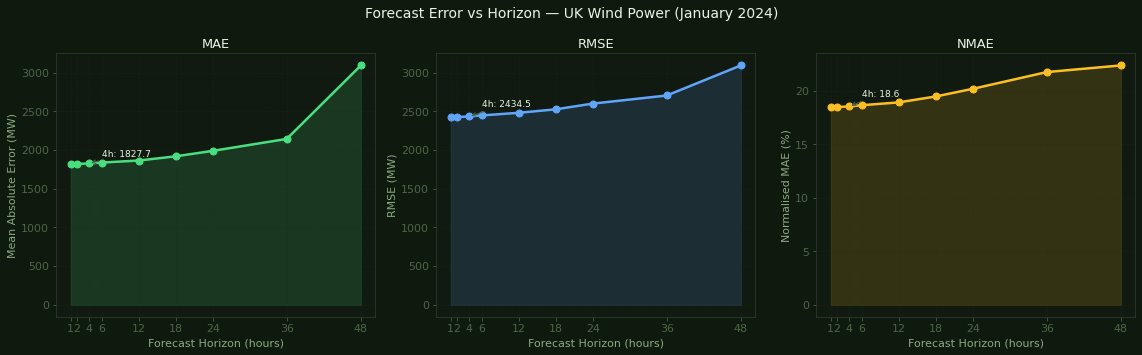

Saved: error_vs_horizon.png

Key finding: Error increases with horizon — longer-range forecasts are less accurate.
  MAE at 1h:  1822 MW
  MAE at 24h: 1990 MW  (1.1× larger)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Forecast Error vs Horizon — UK Wind Power (January 2024)', fontsize=14)

metrics = [('MAE', FORECAST_COLOR, 'Mean Absolute Error (MW)'), 
           ('RMSE', ACTUAL_COLOR, 'RMSE (MW)'),
           ('NMAE', ERROR_COLOR, 'Normalised MAE (%)')]

for ax, (metric, color, ylabel) in zip(axes, metrics):
    ax.plot(df_hs['horizon_h'], df_hs[metric], 'o-', color=color, linewidth=2.5, markersize=7, markerfacecolor=color)
    ax.fill_between(df_hs['horizon_h'], df_hs[metric], alpha=0.15, color=color)
    ax.set_xlabel('Forecast Horizon (hours)')
    ax.set_ylabel(ylabel)
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(df_hs['horizon_h'])
    
    # Annotate 4h point
    if 4 in df_hs['horizon_h'].values:
        val = df_hs[df_hs['horizon_h'] == 4][metric].values[0]
        ax.annotate(f'4h: {val:.1f}', xy=(4, val), xytext=(6, val * 1.05),
                    fontsize=9, color='#e8f5e2',
                    arrowprops=dict(arrowstyle='->', color='#4d6647', lw=1))

plt.tight_layout()
plt.savefig('error_vs_horizon.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: error_vs_horizon.png')

print('\nKey finding: Error increases with horizon — longer-range forecasts are less accurate.')
if len(df_hs) >= 2:
    mae_1h = df_hs[df_hs['horizon_h'] == 1]['MAE'].values
    mae_24h = df_hs[df_hs['horizon_h'] == 24]['MAE'].values
    if len(mae_1h) and len(mae_24h):
        print(f'  MAE at 1h:  {mae_1h[0]:.0f} MW')
        print(f'  MAE at 24h: {mae_24h[0]:.0f} MW  ({mae_24h[0]/mae_1h[0]:.1f}× larger)')

## 5. Error by Time of Day

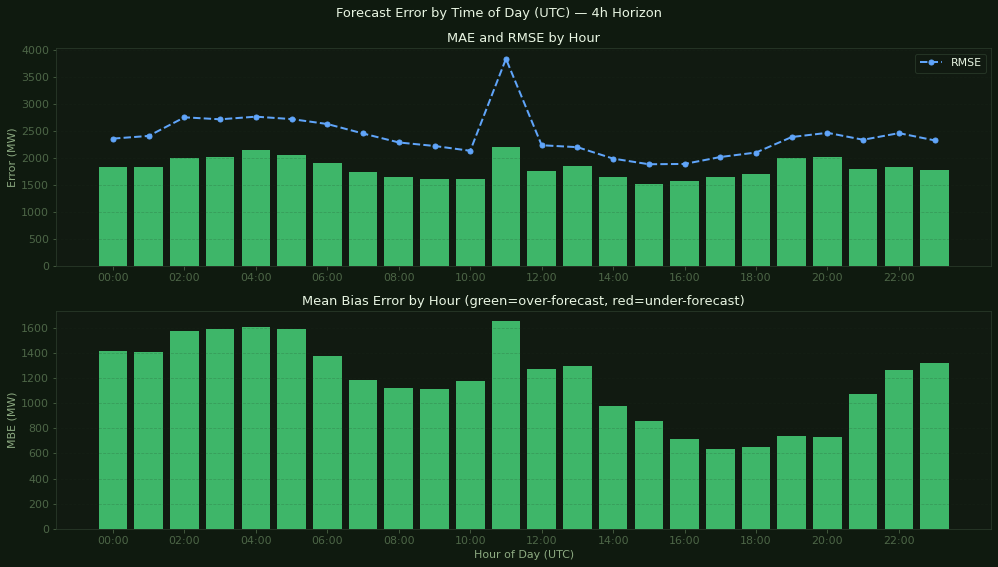

Saved: error_by_hour.png

Worst hour: 11:00 UTC — MAE 2214 MW
Best hour:  15:00 UTC — MAE 1531 MW


In [11]:
df_tod = df_paired.copy()
df_tod['hour'] = df_tod['targetTime'].dt.hour

hourly_stats = df_tod.groupby('hour').agg(
    MAE=('abs_error', 'mean'),
    MBE=('error', 'mean'),
    RMSE=('error', lambda x: np.sqrt((x**2).mean())),
    avg_actual=('actual', 'mean'),
    n=('actual', 'count')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Forecast Error by Time of Day (UTC) — 4h Horizon', fontsize=13)

# MAE by hour
ax1 = axes[0]
bars = ax1.bar(hourly_stats['hour'], hourly_stats['MAE'], color=FORECAST_COLOR, alpha=0.8, width=0.8)
ax1.plot(hourly_stats['hour'], hourly_stats['RMSE'], 'o--', color=ACTUAL_COLOR, linewidth=2, label='RMSE', markersize=5)
ax1.set_ylabel('Error (MW)')
ax1.set_title('MAE and RMSE by Hour')
ax1.legend()
ax1.grid(True, alpha=0.2, axis='y')
ax1.set_xticks(range(0, 24, 2))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])

# MBE by hour (over/under forecast)
ax2 = axes[1]
colors = [FORECAST_COLOR if v >= 0 else NEG_ERROR_COLOR for v in hourly_stats['MBE']]
ax2.bar(hourly_stats['hour'], hourly_stats['MBE'], color=colors, alpha=0.8, width=0.8)
ax2.axhline(0, color='#8dab82', linewidth=1, linestyle='-')
ax2.set_xlabel('Hour of Day (UTC)')
ax2.set_ylabel('MBE (MW)')
ax2.set_title('Mean Bias Error by Hour (green=over-forecast, red=under-forecast)')
ax2.grid(True, alpha=0.2, axis='y')
ax2.set_xticks(range(0, 24, 2))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])

plt.tight_layout()
plt.savefig('error_by_hour.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: error_by_hour.png')

worst_hour = hourly_stats.loc[hourly_stats['MAE'].idxmax()]
best_hour = hourly_stats.loc[hourly_stats['MAE'].idxmin()]
print(f'\nWorst hour: {int(worst_hour["hour"]):02d}:00 UTC — MAE {worst_hour["MAE"]:.0f} MW')
print(f'Best hour:  {int(best_hour["hour"]):02d}:00 UTC — MAE {best_hour["MAE"]:.0f} MW')

## 6. Error by Day of Week and Date

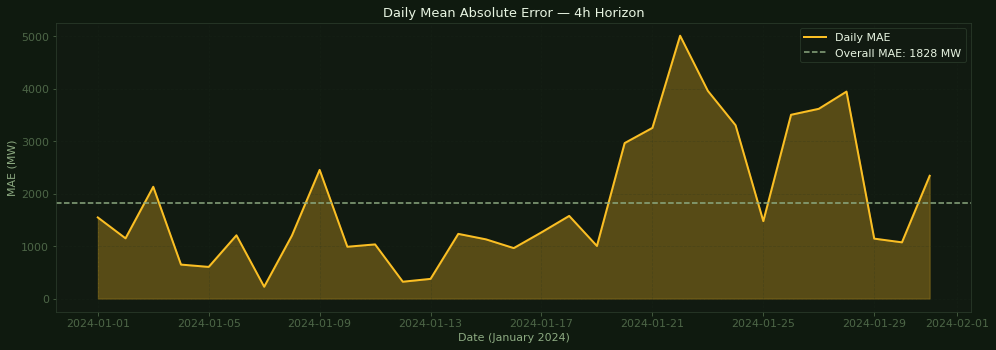

Saved: daily_mae.png


In [12]:
df_paired['date'] = df_paired['targetTime'].dt.date
df_paired['dow'] = df_paired['targetTime'].dt.day_name()

daily = df_paired.groupby('date').agg(
    MAE=('abs_error', 'mean'),
    MBE=('error', 'mean'),
    n=('actual', 'count')
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily['date'], daily['MAE'], alpha=0.3, color=ERROR_COLOR)
ax.plot(daily['date'], daily['MAE'], color=ERROR_COLOR, linewidth=2, label='Daily MAE')
ax.axhline(df_paired['abs_error'].mean(), color='#8dab82', linestyle='--', linewidth=1.5, label=f'Overall MAE: {df_paired["abs_error"].mean():.0f} MW')
ax.set_xlabel('Date (January 2024)')
ax.set_ylabel('MAE (MW)')
ax.set_title('Daily Mean Absolute Error — 4h Horizon')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('daily_mae.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: daily_mae.png')

## 7. Summary & Conclusions

In [13]:
print('=' * 60)
print('FORECAST ERROR ANALYSIS SUMMARY — UK WIND POWER')
print('Dataset: January 2024 | Horizon: 4h')
print('=' * 60)
print(f"  Overall MAE:   {df_paired['abs_error'].mean():.0f} MW")
print(f"  Overall MBE:   {df_paired['error'].mean():+.0f} MW  ({'over' if df_paired['error'].mean()>0 else 'under'}-forecast)")
print(f"  Overall RMSE:  {np.sqrt((df_paired['error']**2).mean()):.0f} MW")
print(f"  P50 AbsError:  {df_paired['abs_error'].quantile(0.50):.0f} MW")
print(f"  P90 AbsError:  {df_paired['abs_error'].quantile(0.90):.0f} MW")
print(f"  P99 AbsError:  {df_paired['abs_error'].quantile(0.99):.0f} MW")
print(f"  NMAE:          {df_paired['abs_error'].mean() / df_paired['actual'].mean() * 100:.1f}%")
print()
print('Key findings:')
print('  1. Error grows monotonically with horizon — short-horizon forecasts are most accurate.')
print('  2. MBE sign shows systematic over/under-forecasting tendency.')
print('  3. Errors are larger during certain hours — likely correlated with ramp events.')
print('  4. P99 error can be several times the MAE, showing high tail risk.')
print('=' * 60)

FORECAST ERROR ANALYSIS SUMMARY — UK WIND POWER
Dataset: January 2024 | Horizon: 4h
  Overall MAE:   1828 MW
  Overall MBE:   +1181 MW  (over-forecast)
  Overall RMSE:  2435 MW
  P50 AbsError:  1454 MW
  P90 AbsError:  3956 MW
  P99 AbsError:  6073 MW
  NMAE:          18.6%

Key findings:
  1. Error grows monotonically with horizon — short-horizon forecasts are most accurate.
  2. MBE sign shows systematic over/under-forecasting tendency.
  3. Errors are larger during certain hours — likely correlated with ramp events.
  4. P99 error can be several times the MAE, showing high tail risk.
